# FPbase protein embedding map — ESM-2 clustering, families & dataset coverage

A map of **every FPbase protein that carries a sequence** (n = 990) in **ESM-2
embedding space**, its unsupervised clustering, and the distributions of the
curated peak / brightness / pKa datasets built from it.

**What this notebook does**

1. Loads the **mean-pooled ESM-2** (`esm2_t33_650M_UR50D`) embedding of all 990
   sequences from `fpbase_output/esm2_650M_mean.npy` (built by
   `embed_all.py`), reduces it (standardize → 50-D PCA), and lays it out in 2-D
   with **t-SNE** (`init="pca"`).
2. Runs **embedding-based clustering** (K-means on the 50-D embedding, K chosen
   by silhouette) and shows what each cluster corresponds to.
3. Annotates the map with the **pipeline exclusions** (cofactor / FAST / opsin,
   from `dataset_pipeline/build_dataset.py`), the **major FP families**, and
   **emission wavelength**.
4. Shows the **size, curation funnel, target distributions, and embedding-space
   coverage** of the curated peak / brightness / pKa datasets.
5. *(Appendix)* compares the ESM-2 layout to the sequence-**identity** layout.

> Run from the `fpbase-extractor/` directory. If the ESM cache is missing, run
> `python embed_all.py` first (a few minutes; downloads ESM-2 weights once).

In [82]:
import os, sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import arcadia_pycolor as apc

apc.mpl.setup()
plt.rcParams["figure.dpi"] = 120
RNG_SEED = 0

# --- paths (relative to fpbase-extractor/) ---
PROT_JSON = "fpbase_output/fpbase_proteins.json"
ESM_NPY   = "fpbase_output/esm2_650M_mean.npy"
ESM_META  = "fpbase_output/esm2_650M_mean.meta.json"
IDENTITY  = "fpbase_output/identity_all.npy"          # appendix comparison only
IDMETA    = "fpbase_output/identity_all.meta.json"
PIPE_DIR  = "../dataset_pipeline"
CURATED   = {                                         # trait -> (dir, target basename)
    "peak":       (f"{PIPE_DIR}/data/peak/curated",       "peaks"),
    "brightness": (f"{PIPE_DIR}/data/brightness/curated", "brightness"),
    "pka":        (f"{PIPE_DIR}/data/pka/curated",        "pka"),
}
sys.path.insert(0, PIPE_DIR)                          # to import the exclusion logic
assert os.path.exists(ESM_NPY), "run `python embed_all.py` first to build the ESM-2 cache"
print("environment ready")

environment ready


## 1. The ESM-2 sequence embedding

### 1.1 Load proteins and the row-aligned ESM-2 cache

`embed_all.py` embeds proteins in the order they appear in `fpbase_proteins.json`
and records a `seq_md5`; we rebuild that order and assert the MD5 matches, so
every embedding row lines up with a row of our table.

In [83]:
proteins = json.load(open(PROT_JSON))

def first_val(p, key):
    return next((s.get(key) for s in (p.get("states") or []) if s.get(key) is not None), None)

recs = []
for p in proteins:
    raw = (p.get("seq") or "").strip().upper()
    if not raw:
        continue
    recs.append(dict(
        slug=p.get("slug", ""), name=p.get("name", ""),
        organism=p.get("parent_organism") or "", seq_len=len(raw),
        ex_max=first_val(p, "ex_max"), em_max=first_val(p, "em_max"),
        _raw=raw, _p=p,
    ))
prot = pd.DataFrame(recs)

meta = json.load(open(ESM_META))
md5 = hashlib.md5("\x00".join(prot["_raw"]).encode()).hexdigest()
assert len(prot) == meta["n"] and md5 == meta["seq_md5"], (
    "ESM cache is stale for this export — rerun `python embed_all.py --force`")
emb = np.load(ESM_NPY)                                # (N, 1280) mean-pooled ESM-2
print(f"{len(prot)} proteins; ESM-2 embedding {emb.shape} "
      f"({meta['model']}, layer {meta['layer']}, {meta['pooling']}-pooled) aligned OK")
prot.drop(columns=["_raw", "_p"]).head(3)

990 proteins; ESM-2 embedding (990, 1280) (esm2_t33_650M_UR50D, layer 33, mean-pooled) aligned OK


,slug,name,organism,seq_len,ex_max,em_max
0,10b,10B,Aequorea victoria,238,513.0,525.0
1,11,11,Aequorea victoria,238,502.0,512.0
2,22g,22G,Echinophyllia sp. SC22,224,NaN,NaN


### 1.2 Classify pipeline exclusions

Using the **exact** functions from `dataset_pipeline/build_dataset.py`, so the
labels match what the training-data builder drops: **cofactor** (biliverdin /
FAD / bilirubin — signal from a bound ligand), **fluorogen (FAST)**, **opsin /
channelrhodopsin**, a **manual IR-FP**, **non-standard residues**, and
**no reported ex/em**. Everything else is a **kept** genuine FP.

In [84]:
from build_dataset import is_exogenous, clean_seq   # the real pipeline logic

def exclusion_reason(p):
    exo = is_exogenous(p)                     # 'cofactor'|'fluorogen'|'opsin'|'manual_irfp'|None
    if exo:
        return exo
    _, ok = clean_seq(p.get("seq"))
    if not ok:
        return "nonstandard_aa"
    states = p.get("states") or []
    if not any(s.get("ex_max") is not None and s.get("em_max") is not None for s in states):
        return "no_emission"
    return "kept"

EXC_LABEL = {
    "kept": "kept (genuine FP)", "cofactor": "cofactor-dependent",
    "fluorogen": "fluorogen-activating (FAST)", "opsin": "opsin / channelrhodopsin",
    "manual_irfp": "IR-FP (biliverdin, manual)", "nonstandard_aa": "non-standard residues",
    "no_emission": "no reported ex/em",
}
prot["exclusion"] = prot["_p"].map(exclusion_reason)
prot["exclusion_label"] = prot["exclusion"].map(EXC_LABEL)
print(prot["exclusion_label"].value_counts().to_string())

exclusion_label
kept (genuine FP)              769
no reported ex/em              138
cofactor-dependent              63
non-standard residues           14
fluorogen-activating (FAST)      4
opsin / channelrhodopsin         1
IR-FP (biliverdin, manual)       1


### 1.3 Assign a major FP family

From FPbase's curated `parent_organism`, which tracks FP lineage. The long tail
of single-organism entries falls into *other* / *synthetic*.

In [85]:
import re
FAMILY_RULES = [
    ("GFP family — Aequorea",               r"Aequorea"),
    ("DsRed / mFruits — Discosoma",         r"Discosoma"),
    ("eqFP / mKate / mScarlet — Entacmaea", r"Entacmaea"),
    ("Faviina — Kaede / EosFP / Dendra",    r"Lobophyllia|Echinophyllia|Verrillofungia|Montastraea|"
                                            r"Favia|Trachyphyllia|Galaxea|Mycedium|Catalaphyllia|"
                                            r"Scleractinia|Platygyra|Cyphastrea|Dendronephthya"),
    ("Clavularia — mTFP / Kusabira",        r"Clavularia"),
    ("Zoanthus — ZsGreen / ZsYellow",       r"Zoanthus"),
    ("Acropora / Montipora corals",         r"Acropora|Montipora"),
    ("StayGold — Cytaeis",                  r"Cytaeis"),
    ("LanYFP / mNeonGreen — Branchiostoma", r"Branchiostoma"),
    ("Bacteriophytochrome IR-FPs",          r"Rhodopseudomonas|Deinococcus|Bradyrhizobium|"
                                            r"Agrobacterium|Xanthomonas|Idiomarina"),
    ("Flavin-based (LOV / miniSOG)",        r"Arabidopsis|Bacillus|Pseudomonas"),
]
def family_of(org):
    for label, pat in FAMILY_RULES:
        if re.search(pat, org, re.I):
            return label
    return "synthetic / unassigned" if org in ("", "synthetic construct") else "other"

prot["family"] = prot["organism"].map(family_of)
print(prot["family"].value_counts().to_string())

family
GFP family — Aequorea                  315
other                                  160
Faviina — Kaede / EosFP / Dendra       117
DsRed / mFruits — Discosoma             97
eqFP / mKate / mScarlet — Entacmaea     85
synthetic / unassigned                  50
Acropora / Montipora corals             49
Bacteriophytochrome IR-FPs              33
Clavularia — mTFP / Kusabira            27
StayGold — Cytaeis                      17
Flavin-based (LOV / miniSOG)            15
Zoanthus — ZsGreen / ZsYellow           13
LanYFP / mNeonGreen — Branchiostoma     12


### 1.4 Shared color maps

Fixed family / exclusion palettes so every panel below is colored consistently.

In [86]:
palette = [str(c) for c in apc.palettes.all_ordered]
GRAY = {"other": "#C4C4C4", "synthetic / unassigned": "#DFDFDF"}
fam_order = prot.family.value_counts().index.tolist()
named_fams = [f for f in fam_order if f not in GRAY]
FAM_COLOR = {f: palette[i % len(palette)] for i, f in enumerate(named_fams)}
FAM_COLOR.update(GRAY)

EXC_ORDER = ["cofactor", "fluorogen", "opsin", "manual_irfp", "nonstandard_aa", "no_emission"]
EXC_COLOR = {r: c for r, c in zip(EXC_ORDER, palette)}

def label_points(ax, xy, texts, min_pts=1, declutter=False):
    """Place each text at the densest point of its group.

    Each entry in `texts` is (points, text) or (points, text, color); the color
    tints the label (defaults to dark gray). With declutter=True, labels that
    would collide are pushed apart vertically and linked back to their anchor
    with a thin leader line in the same color.
    """
    if len(xy) == 0:
        return
    xr, yr = np.ptp(xy[:, 0]), np.ptp(xy[:, 1])
    radius = 0.05 * np.hypot(xr, yr)
    items = []
    for entry in texts:
        P, t = entry[0], entry[1]
        col = entry[2] if len(entry) > 2 else "#222"
        if len(P) < min_pts:
            continue
        dens = cKDTree(P).query_ball_point(P, radius, return_length=True)
        ax0, ay0 = P[int(np.argmax(dens))]
        items.append({"x": ax0, "y": ay0, "ax": ax0, "ay": ay0, "t": t, "c": col})
    if declutter and items:                       # greedy vertical de-overlap (labels only move up)
        min_dy, band = 0.07 * yr, 0.40 * xr
        items.sort(key=lambda e: e["y"])
        for i in range(1, len(items)):
            for j in range(i):
                if abs(items[i]["x"] - items[j]["x"]) < band and \
                        items[i]["y"] < items[j]["y"] + min_dy:
                    items[i]["y"] = items[j]["y"] + min_dy
    for it in items:
        if abs(it["y"] - it["ay"]) > 1e-9 or abs(it["x"] - it["ax"]) > 1e-9:
            ax.plot([it["ax"], it["x"]], [it["ay"], it["y"]], color=it["c"], lw=0.6, alpha=0.6, zorder=2)
        ax.annotate(it["t"], (it["x"], it["y"]), fontsize=9, fontweight="regular",
                    ha="center", va="center", color=it["c"], zorder=3,
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))

print(f"{len(named_fams)} named families + {len(EXC_ORDER)} exclusion classes")

11 named families + 6 exclusion classes


### 1.5 Reduce and lay out the embedding

Standardize the 1280-D ESM-2 vectors, compress to **50 principal components**
(the representation we cluster on), then **t-SNE** to 2-D for display.

In [87]:
Zstd = (emb - emb.mean(0)) / (emb.std(0) + 1e-6)
pca = PCA(n_components=50, random_state=RNG_SEED)
Z50 = pca.fit_transform(Zstd)
print(f"50-PC embedding: {Z50.shape}  ({pca.explained_variance_ratio_.sum():.1%} variance retained)")

xy = TSNE(n_components=2, metric="euclidean", init="pca", perplexity=30,
          learning_rate="auto", random_state=RNG_SEED).fit_transform(Z50)
prot["x"], prot["y"] = xy[:, 0], xy[:, 1]
XY = prot[["x", "y"]].to_numpy()
print("t-SNE layout:", xy.shape)

50-PC embedding: (990, 50)  (94.8% variance retained)
t-SNE layout: (990, 2)


## 2. Embedding-based clustering

Cluster the **50-D ESM-2 embedding** with K-means, choosing K by the silhouette
score over a range, then read off what each cluster is.

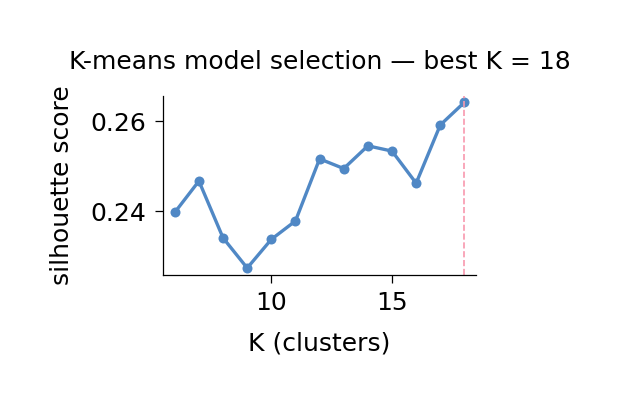

K-means K=18; cluster sizes:
cluster_name
C0: Clavularia                           51
C10: GFP family                          71
C11: Trichodesmium erythraeum IMS101      6
C12: Acropora millepora                  78
C13: Nostoc punctiforme                   3
C14: Faviina                             93
C15: Halorhodospira halophila             9
C16: Bacteriophytochrome IR-FPs           6
C17: Anguilla japonica                    4
C1: Verrillofungia concinna             120
C2: GFP family                          239
C3: DsRed / mFruits                      14
C4: Bacteriophytochrome IR-FPs           31
C5: Cytaeis uchidae                      44
C6: Flavin-based (LOV / miniSOG)         14
C7: eqFP / mKate / mScarlet              82
C8: DsRed / mFruits                      90
C9: Dendronephthya sp.                   35


In [88]:
Ks = list(range(6, 19))
sils = [silhouette_score(Z50, KMeans(k, n_init=10, random_state=RNG_SEED).fit_predict(Z50))
        for k in Ks]
bestK = Ks[int(np.argmax(sils))]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(Ks, sils, "-o", color=str(apc.aegean))
ax.axvline(bestK, ls="--", color=str(apc.rose), lw=1)
ax.set(xlabel="K (clusters)", ylabel="silhouette score",
       title=f"K-means model selection — best K = {bestK}")
plt.tight_layout(); plt.show()

km = KMeans(bestK, n_init=10, random_state=RNG_SEED).fit(Z50)
prot["cluster"] = km.labels_

# name each cluster by its dominant family (fall back to dominant organism)
cl_name = {}
for c in range(bestK):
    sub = prot[prot.cluster == c]
    fam = sub.family.mode().iloc[0]
    if fam in GRAY:
        org = sub.organism.replace("", np.nan).mode()
        tag = (org.iloc[0] if len(org) else "mixed")
    else:
        tag = fam.split(" — ")[0]
    cl_name[c] = f"C{c}: {tag}"
prot["cluster_name"] = prot.cluster.map(cl_name)
print(f"K-means K={bestK}; cluster sizes:\n" +
      prot.cluster_name.value_counts().sort_index().to_string())

### 2.1 Map colored by embedding cluster

The unsupervised K-means partition of ESM-2 space, laid out by t-SNE and labeled
by each cluster's dominant family.

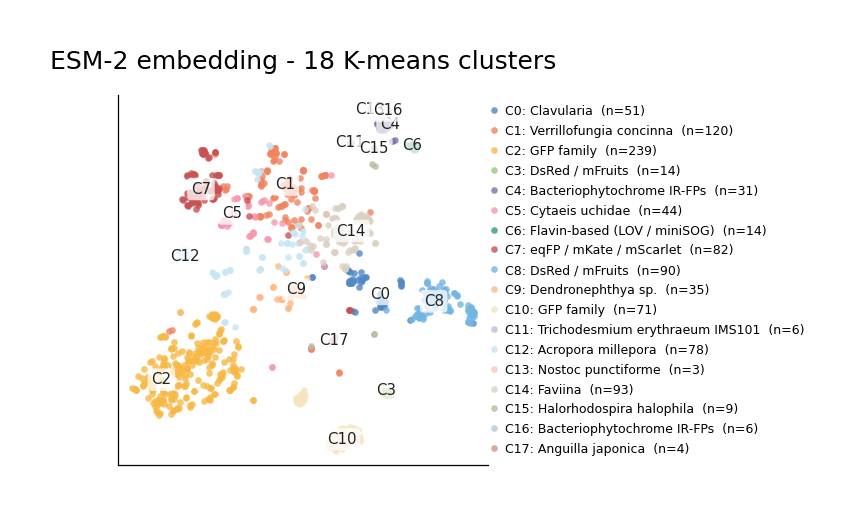

In [89]:
fig, ax = plt.subplots(figsize=(4,4))
cl_palette = [str(c) for c in apc.palettes.all_ordered]
texts = []
for c in range(bestK):
    sub = prot[prot.cluster == c]
    ax.scatter(sub.x, sub.y, s=16, c=cl_palette[c % len(cl_palette)], alpha=0.8,
               linewidths=0, label=cl_name[c] + f"  (n={len(sub)})")
    texts.append((sub[["x", "y"]].to_numpy(), f"C{c}"))
label_points(ax, XY, texts)
ax.set(xticks=[], yticks=[], title=f"ESM-2 embedding - 18 K-means clusters")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=7.5)
ax.set_box_aspect(1)
plt.show()

### 2.2 What each cluster corresponds to

Cluster × family composition. Clean diagonal-ish structure means the
unsupervised ESM-2 clusters recover the known FP families.

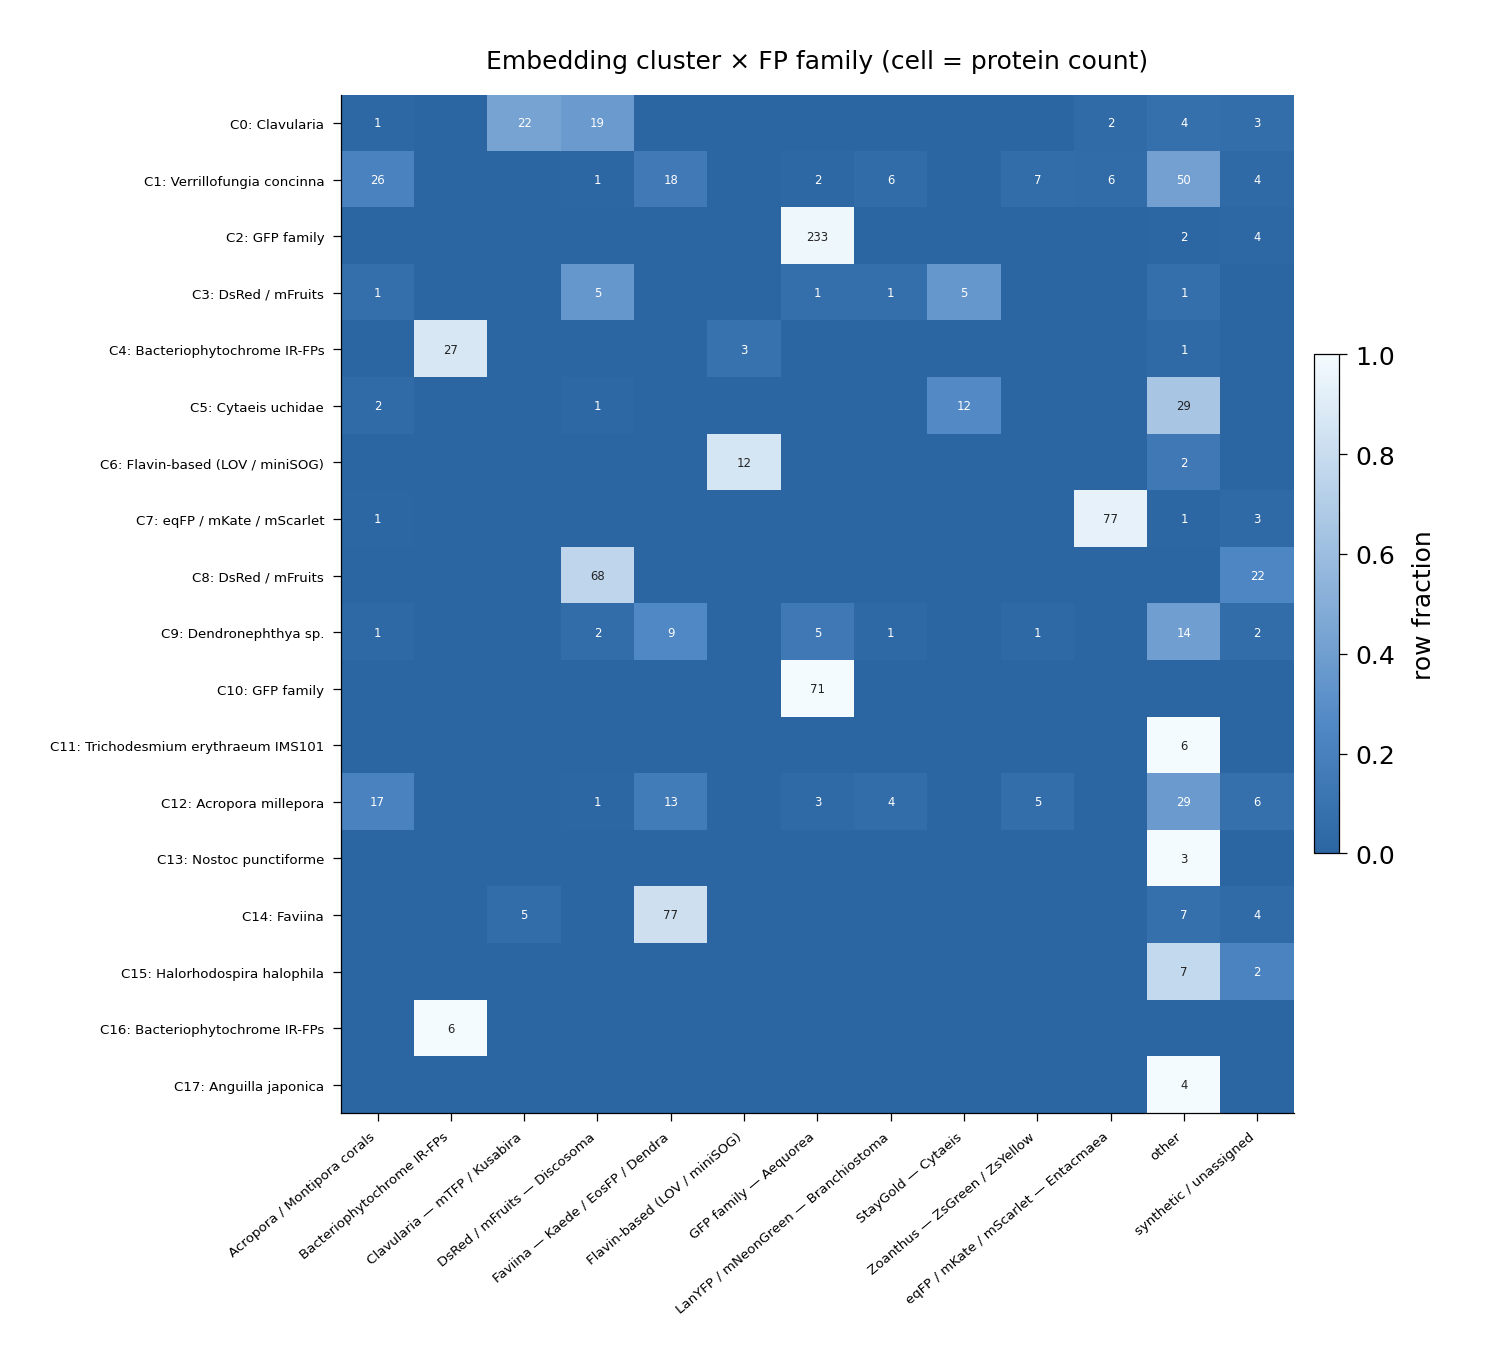

In [90]:
ct = pd.crosstab(prot.cluster_name, prot.family)
ct = ct.reindex(sorted(ct.index, key=lambda s: int(s.split(":")[0][1:])))
frac = ct.div(ct.sum(1), axis=0)

fig, ax = plt.subplots(figsize=(12, 0.5 * len(ct) + 2))
im = ax.imshow(frac.values, cmap=apc.gradients.blues.to_mpl_cmap(), aspect="auto",
               vmin=0, vmax=1)
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index, fontsize=8)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        n = ct.values[i, j]
        if n:
            ax.text(j, i, n, ha="center", va="center", fontsize=7,
                    color="#222" if frac.values[i, j] > 0.5 else "white")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02).set_label("row fraction")
ax.set_title("Embedding cluster × FP family (cell = protein count)")
plt.tight_layout(); plt.show()

## 3. Annotated maps

### 3.1 Pipeline exclusions

Kept genuine FPs are the gray backdrop; each excluded class is highlighted. In
ESM-2 space the cofactor-dependent proteins (biliverdin IR-FPs, FAD/FMN LOV) and
the opsin pull well away from the β-barrel FPs — which is exactly why they are
dropped from the sequence→phenotype datasets.

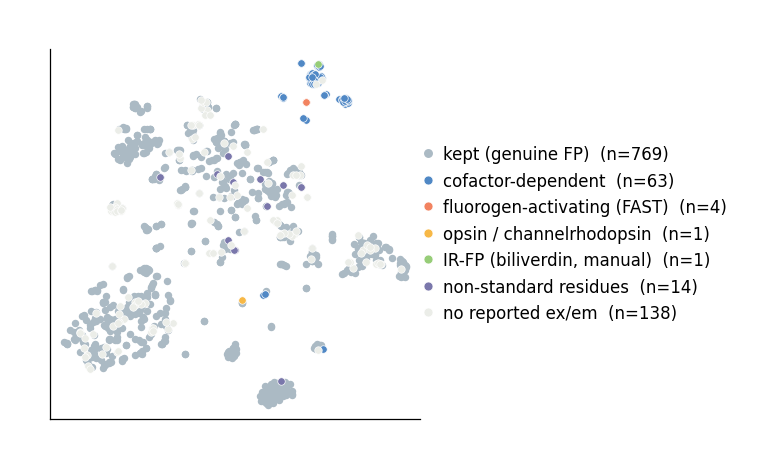

In [91]:
fig, ax = plt.subplots(figsize=(6,4))
kept = prot[prot.exclusion == "kept"]
ax.scatter(kept.x, kept.y, s=20, c=str(apc.cloud), alpha=1, linewidths=0,
           label=f"{EXC_LABEL['kept']}  (n={len(kept)})")
for r in EXC_ORDER:
    sub = prot[prot.exclusion == r]
    if len(sub) == 0:
        continue
    if EXC_LABEL[r] == 'no reported ex/em':
        ax.scatter(sub.x, sub.y, s=20, c=str(apc.gray), edgecolors="white", linewidths=0.4,
                label=f"{EXC_LABEL[r]}  (n={len(sub)})")
    else:
        ax.scatter(sub.x, sub.y, s=20, c=EXC_COLOR[r], edgecolors="white", linewidths=0.4,
                label=f"{EXC_LABEL[r]}  (n={len(sub)})")
ax.set(xticks=[], yticks=[])#, title="ESM-2 map — pipeline exclusions (genuine FP vs. dropped)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=10, markerscale=1.2)
ax.set_box_aspect(1)
plt.show()

### 3.2 Major FP families

In [ ]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6,4))
texts = []
for f in fam_order:
    sub = prot[prot.family == f]
    ax.scatter(sub.x, sub.y, s=16, color=FAM_COLOR[f], alpha=0.8, linewidths=0)
    if f in named_fams and len(sub) >= 25:
        texts.append((sub[["x", "y"]].to_numpy(), f.split(" — ")[0], FAM_COLOR[f]))
label_points(ax, XY, texts, declutter=True)   # tint labels by family color; separate colliding labels
# explicit legend handles keyed to FAM_COLOR -> swatches match the scatter colors exactly
handles = [Line2D([0], [0], marker="o", linestyle="", markersize=7,
                  markerfacecolor=FAM_COLOR[f], markeredgecolor="none",
                  label=f"{f}  (n={len(prot[prot.family == f])})")
           for f in fam_order]
ax.set(xticks=[], yticks=[], title="major FP families")
ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5),
          frameon=False, fontsize=10, markerscale=1.2)
ax.set_box_aspect(1); plt.show()

### 3.3 Emission wavelength (sanity check)

Coloring the kept FPs by emission maximum: identity neighbors also share color,
and the green→red gradient tracks the GFP → DsRed/mFruits split.

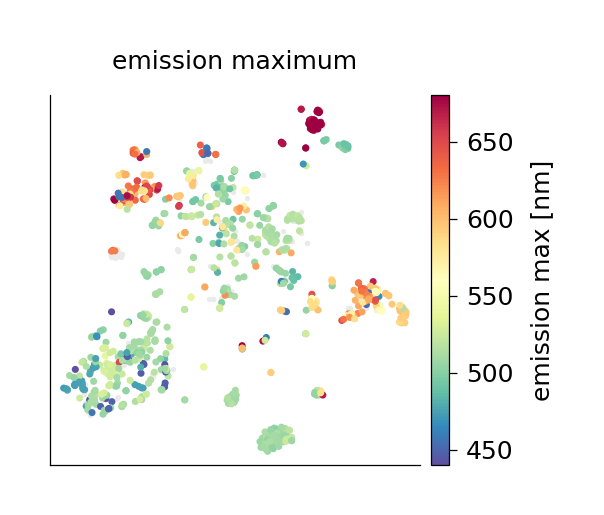

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(prot.x, prot.y, s=10, c="#EAEAEA", linewidths=0)
sub = prot.dropna(subset=["em_max"])
sc = ax.scatter(sub.x, sub.y, c=sub.em_max, cmap="Spectral_r", vmin=440, vmax=680,
                s=18, linewidths=0)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02).set_label("emission max [nm]")
ax.set(xticks=[], yticks=[], title="emission maximum")
ax.set_box_aspect(1); plt.show()

### 3.4 Excitation wavelength

The same map colored by excitation maximum, mirroring §3.3.

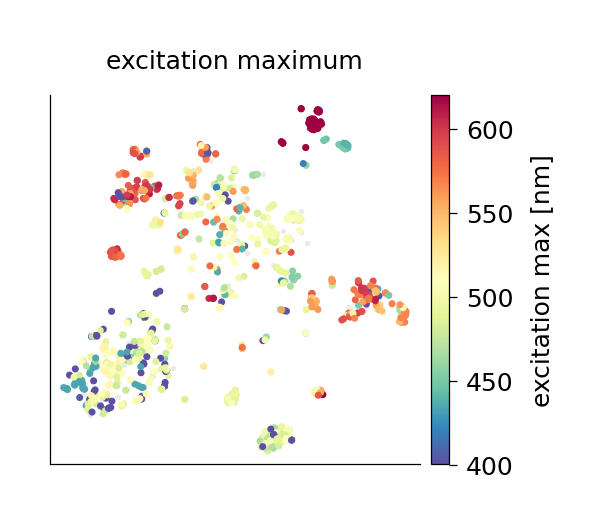

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(prot.x, prot.y, s=10, c="#EAEAEA", linewidths=0)
sub = prot.dropna(subset=["ex_max"])
sc = ax.scatter(sub.x, sub.y, c=sub.ex_max, cmap="Spectral_r", vmin=400, vmax=620,
                s=18, linewidths=0)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02).set_label("excitation max [nm]")
ax.set(xticks=[], yticks=[], title="excitation maximum")
ax.set_box_aspect(1); plt.show()

## 4. Curated dataset distributions

`dataset_pipeline/build_dataset.py` turns the genuine-FP superset into three
trait datasets (peak ex/em, brightness, pKa).

In [ ]:
def load_trait(trait):
    d, base = CURATED[trait]
    arr  = np.load(os.path.join(d, f"{base}.npy"))
    rows = pd.read_csv(os.path.join(d, f"{base}_assignments.csv"))
    tmeta = json.load(open(os.path.join(d, "curate_meta.json")))
    return arr, rows, tmeta

datasets = {t: load_trait(t) for t in CURATED}
for t, (arr, rows, tmeta) in datasets.items():
    print(f"{t:10s} N={len(rows):4d}  target array {str(arr.shape):9s}  "
          f"unique seqs={tmeta['counts']['unique_sequences']}")

peak       N= 758  target array (758, 2)   unique seqs=758
brightness N= 533  target array (533, 1)   unique seqs=533
pka        N= 368  target array (368, 1)   unique seqs=368


### 4.1 Curation funnel and dataset sizes

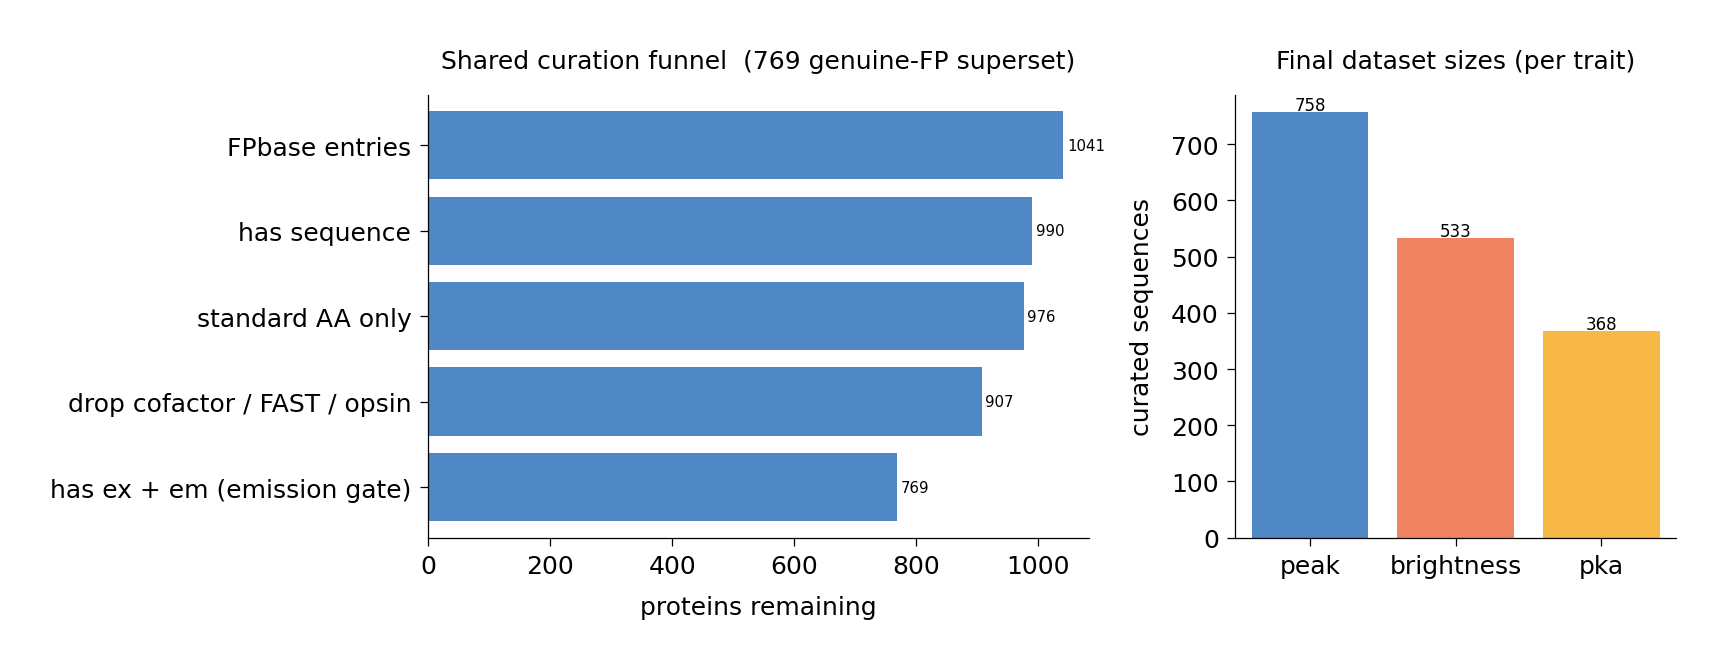

In [ ]:
c = datasets["peak"][2]["counts"]        # Stage A/B counts are shared across traits
n_entries = len(proteins)
n_seq     = n_entries - c["skipped_no_sequence"]
n_std     = n_seq - c["skipped_nonstandard_aa"]
n_genuine = n_std - c["skipped_exogenous"]
n_super   = n_genuine - c["skipped_no_emission_states"]
funnel = [("FPbase entries", n_entries), ("has sequence", n_seq),
          ("standard AA only", n_std), ("drop cofactor / FAST / opsin", n_genuine),
          ("has ex + em (emission gate)", n_super)]
vals = [v for _, v in funnel]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})
axL.barh(range(len(vals)), vals, color=str(apc.aegean), edgecolor="white")
axL.set_yticks(range(len(vals))); axL.set_yticklabels([l for l, _ in funnel]); axL.invert_yaxis()
for i, v in enumerate(vals):
    axL.text(v + 6, i, str(v), va="center", fontsize=9)
axL.set_xlabel("proteins remaining")
axL.set_title(f"Shared curation funnel  ({n_super} genuine-FP superset)")

sizes = {t: len(datasets[t][1]) for t in CURATED}
bars = axR.bar(list(sizes), list(sizes.values()),
               color=[str(c) for c in apc.palettes.all_ordered[:len(sizes)]], edgecolor="white")
for b, v in zip(bars, sizes.values()):
    axR.text(b.get_x() + b.get_width()/2, v + 3, str(v), ha="center", fontsize=10)
axR.set_ylabel("curated sequences"); axR.set_title("Final dataset sizes (per trait)")
plt.tight_layout(); plt.show()

### 4.2 Target-value distributions

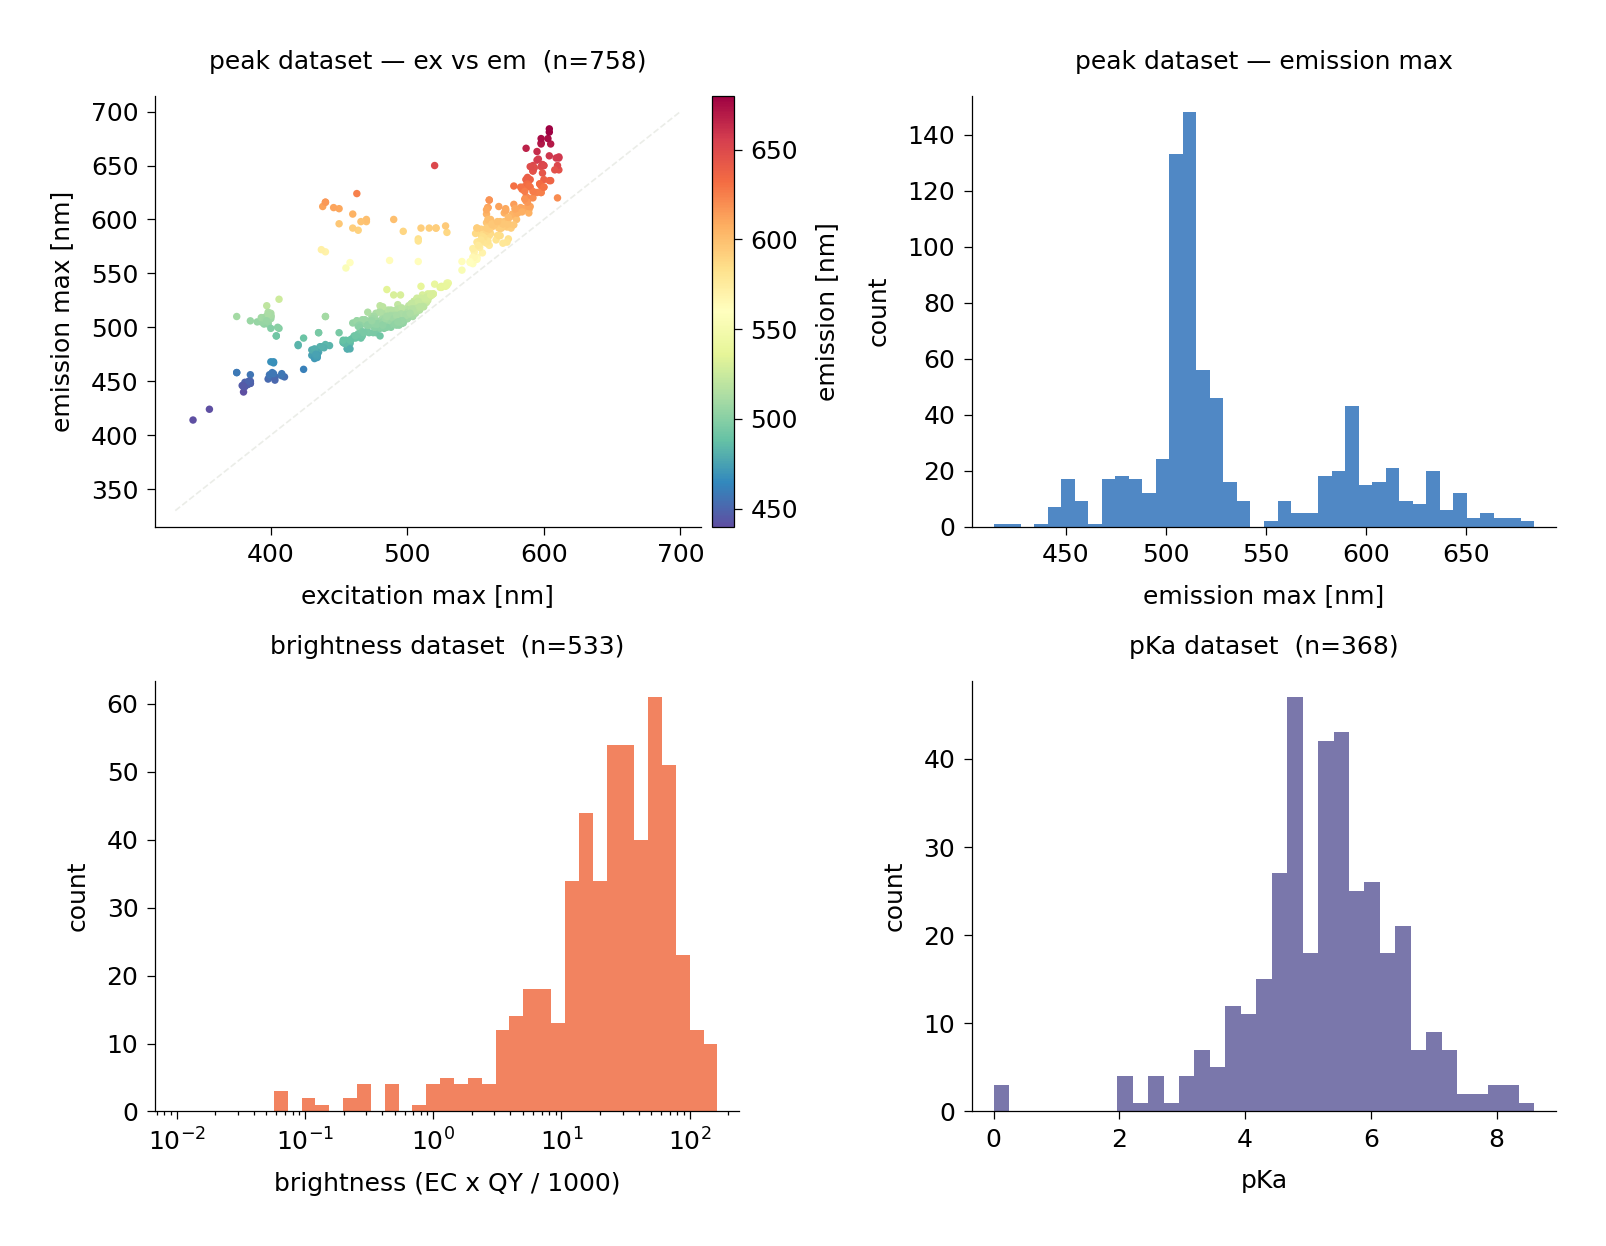

In [ ]:
peak_arr = datasets["peak"][0]
bri_arr  = datasets["brightness"][0][:, 0]
pka_arr  = datasets["pka"][0][:, 0]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ax = axes[0, 0]
sc = ax.scatter(peak_arr[:, 0], peak_arr[:, 1], c=peak_arr[:, 1], cmap="Spectral_r",
                s=20, linewidths=0, vmin=440, vmax=680)
ax.plot([330, 700], [330, 700], ls="--", c=str(apc.gray), lw=1)
ax.set(xlabel="excitation max [nm]", ylabel="emission max [nm]",
       title=f"peak dataset — ex vs em  (n={len(peak_arr)})")
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02).set_label("emission [nm]")

axes[0, 1].hist(peak_arr[:, 1], bins=40, color=str(apc.aegean), edgecolor="white")
axes[0, 1].set(xlabel="emission max [nm]", ylabel="count", title="peak dataset — emission max")

pos = bri_arr[bri_arr > 0]
axes[1, 0].hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40),
                color=str(apc.amber), edgecolor="white")
axes[1, 0].set_xscale("log")
axes[1, 0].set(xlabel="brightness (EC x QY / 1000)", ylabel="count",
               title=f"brightness dataset  (n={len(bri_arr)})")

axes[1, 1].hist(pka_arr, bins=35, color=str(apc.aster), edgecolor="white")
axes[1, 1].set(xlabel="pKa", ylabel="count", title=f"pKa dataset  (n={len(pka_arr)})")
plt.tight_layout(); plt.show()

### 4.3 Embedding-space coverage of each dataset

Each curated dataset overlaid on the ESM-2 map — showing the sampling bias
toward the dense Aequorea GFP region that motivates identity-aware splitting.

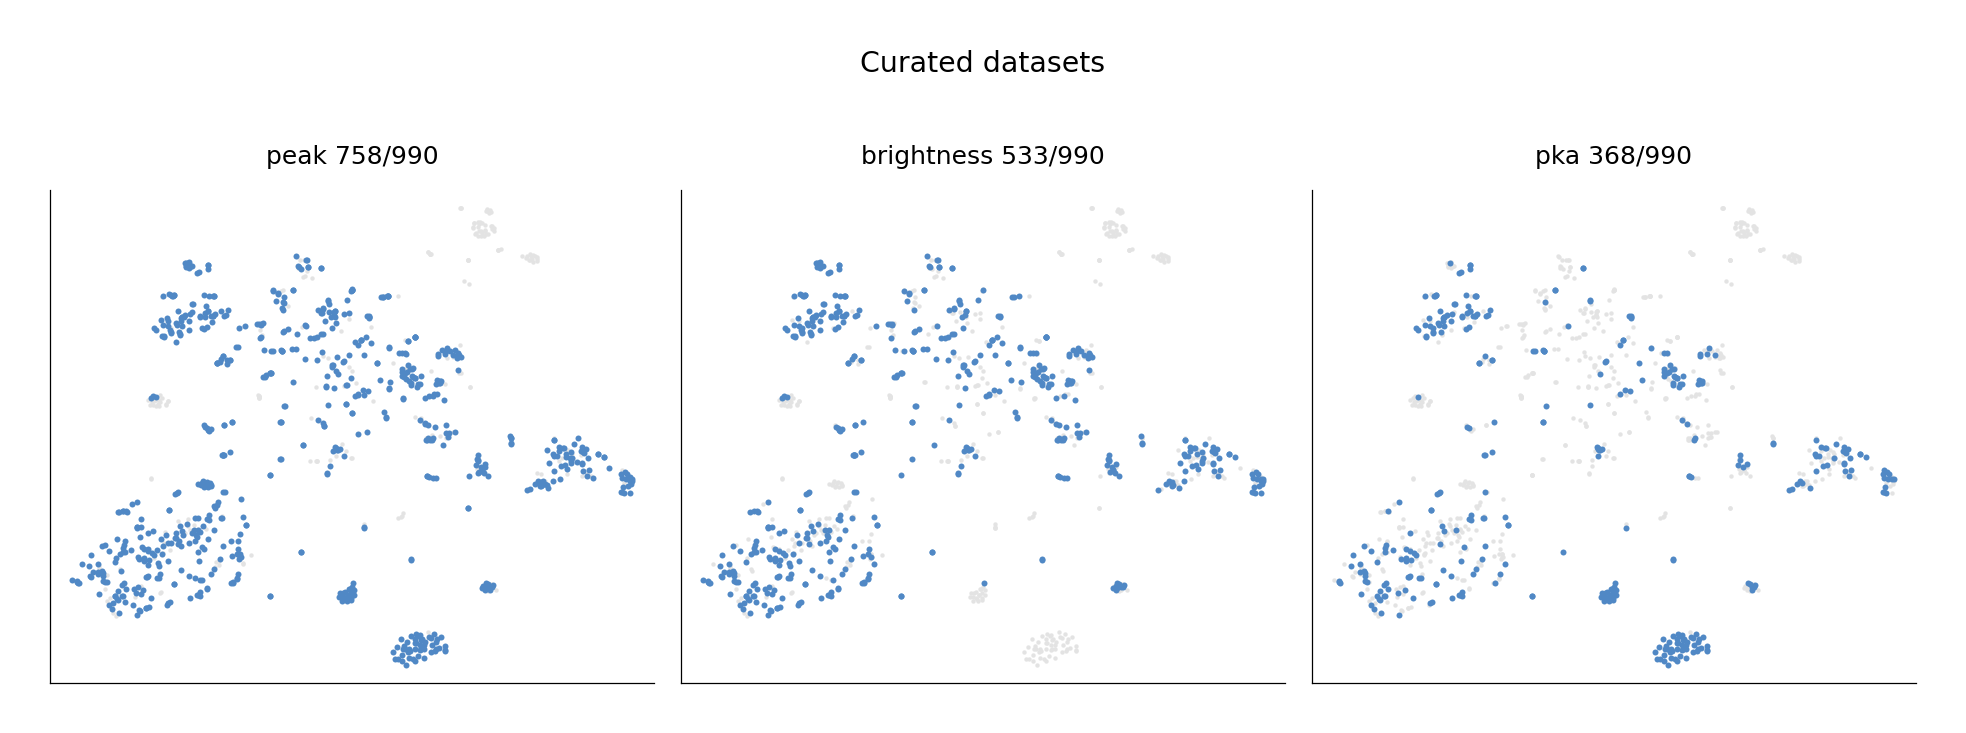

In [ ]:
slug2xy = prot.set_index("slug")[["x", "y"]]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
for ax, t in zip(axes, CURATED):
    rows = datasets[t][1]
    ax.scatter(prot.x, prot.y, s=7, c="#E3E3E3", linewidths=0)
    cov = slug2xy.reindex(rows["slug"].unique()).dropna()
    ax.scatter(cov.x, cov.y, s=13, c=str(apc.aegean), linewidths=0)
    ax.set(xticks=[], yticks=[], title=f"{t} {len(cov)}/{len(prot)}")
fig.suptitle("Curated datasets", y=1.02)
plt.tight_layout(); plt.show()

## Appendix — ESM-2 vs. sequence-identity layout

For reference, the same 990 proteins laid out two ways: the ESM-2 embedding
(this notebook) vs. the pairwise sequence-**identity** matrix
(`identity_all.npy`, `metric="precomputed"`). Families stay grouped in both
(same biology); the geometry differs because the representation and metric do.
The identity matrix rows share this table's ordering, so they align directly.

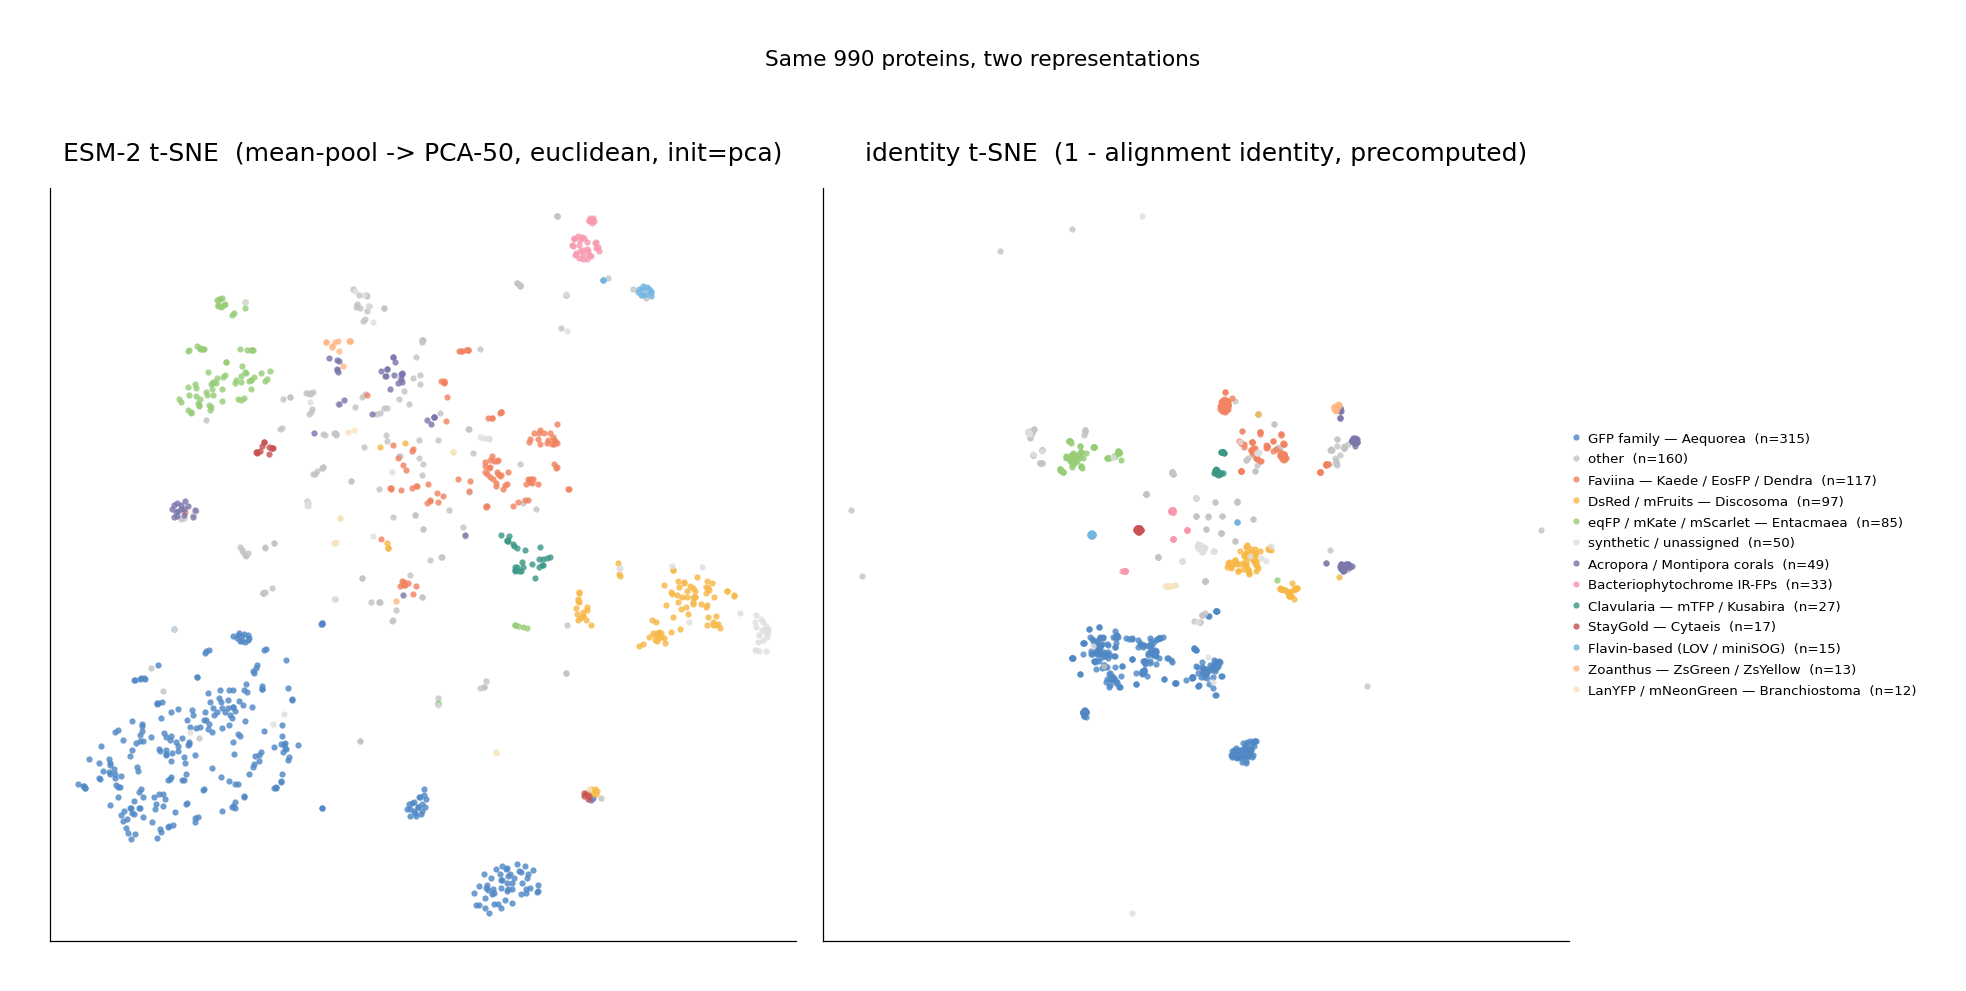

In [ ]:
idmeta = json.load(open(IDMETA))
from Bio.Align import substitution_matrices
ALPHA = set(substitution_matrices.load("BLOSUM62").alphabet)
xseq = ["".join(ch if ch in ALPHA else "X" for ch in s) for s in prot["_raw"]]
assert hashlib.md5("\x00".join(xseq).encode()).hexdigest() == idmeta["seq_md5"], \
    "identity matrix not aligned to this export"

M = np.load(IDENTITY)
D = 1.0 - M; D = (D + D.T) / 2.0; np.fill_diagonal(D, 0.0)
id_xy = TSNE(n_components=2, metric="precomputed", init="random", perplexity=30,
             random_state=RNG_SEED).fit_transform(D)

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
for f in fam_order:
    m = (prot.family == f).to_numpy()
    axes[0].scatter(prot.x[m], prot.y[m], s=14, c=FAM_COLOR[f], alpha=0.82, linewidths=0)
    axes[1].scatter(id_xy[m, 0], id_xy[m, 1], s=14, c=FAM_COLOR[f], alpha=0.82, linewidths=0,
                    label=f"{f}  (n={int(m.sum())})")
axes[0].set_title("ESM-2 t-SNE  (mean-pool -> PCA-50, euclidean, init=pca)")
axes[1].set_title("identity t-SNE  (1 - alignment identity, precomputed)")
for ax in axes:
    ax.set(xticks=[], yticks=[])
axes[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8)
fig.suptitle("Same 990 proteins, two representations", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

---
### Notes & provenance

- **Embedding:** mean-pooled `esm2_t33_650M_UR50D` (layer 33) over all 990 FPbase
  sequences, cached by `embed_all.py` to `fpbase_output/esm2_650M_mean.npy`. The
  `seq_md5` assert in §1.1 guarantees row alignment; re-pull FPbase → rerun
  `embed_all.py --force`.
- **Clustering** is K-means on the standardized 50-D PCA of the embedding, with K
  chosen by silhouette. It is unsupervised — the cluster×family panel shows how
  well it recovers the known lineages.
- **Exclusion labels** come directly from `dataset_pipeline/build_dataset.py`
  (`is_exogenous`, `clean_seq`); **families** from FPbase `parent_organism`.
- **t-SNE** is for visualization only (inter-cluster distances are not
  quantitative; axes have no fixed orientation). The clustering is done on the
  50-D embedding, not the 2-D layout.

## 5. Sequence naturalness — ESM-2 pseudo-perplexity

How "natural" each FPbase sequence looks to the ESM-2 masked language model.
For every residue we mask that position and read the model's log-probability of
the true amino acid given the rest of the chain, then

$$\mathrm{PPPL} = \exp\!\Big(-\tfrac{1}{L}\sum_{i=1}^{L}\log p(x_i \mid x_{\setminus i})\Big).$$

Lower = more predictable / natural under ESM-2. This is a masked-marginal
(pseudo) perplexity — one forward pass per masked position — so it is the
heaviest cell in the notebook (order minutes on GPU/MPS). Results are cached to
`fpbase_output/esm2_650M_pppl.npy`, keyed by the same `seq_md5` used for the
embedding, and reused on rerun.

In [ ]:
import time
import torch
import torch.nn.functional as F
sys.path.insert(0, "../peak_design")                     # peak_models.py (ESM-2 utilities) lives here
import peak_models as pm                                  # ESM-2 loader shared with embed_all.py

PPPL_NPY  = "fpbase_output/esm2_650M_pppl.npy"
PPPL_META = "fpbase_output/esm2_650M_pppl.meta.json"
SUB_BS    = 32                                            # masked variants scored per forward pass

def _device():
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

dev = _device()
model, alphabet, bc = pm.get_esm(dev)                     # (esm2_t33_650M_UR50D, alphabet, batch_converter)
_alpha = set(alphabet.tok_to_idx)
esm_seqs = ["".join(c if c in _alpha else "X" for c in s) for s in prot["_raw"]]   # map rare AAs -> X

@torch.no_grad()
def seq_pppl(seq):
    """exp(mean masked-residue NLL) for one sequence (one position masked at a time)."""
    _, _, toks = bc([("s", seq)])                         # (1, L+2): BOS + residues + EOS
    toks = toks[0]
    L = len(seq)
    pos = torch.arange(1, L + 1)                          # residue token positions (BOS at 0)
    nll = 0.0
    for i in range(0, L, SUB_BS):
        pb = pos[i:i + SUB_BS]
        batch = toks.unsqueeze(0).repeat(len(pb), 1).clone()
        rows = torch.arange(len(pb))
        batch[rows, pb] = alphabet.mask_idx               # mask one distinct position per row
        lp = F.log_softmax(model(batch.to(dev))["logits"].float(), dim=-1)
        nll += -lp[rows, pb, toks[pb].to(dev)].sum().item()
    return float(np.exp(nll / L))

want_md5 = meta["seq_md5"]
if (os.path.exists(PPPL_NPY) and os.path.exists(PPPL_META)
        and json.load(open(PPPL_META)).get("seq_md5") == want_md5):
    pppl = np.load(PPPL_NPY)
    print(f"loaded cached PPPL for {len(pppl)} sequences")
else:
    t0 = time.time()
    pppl = np.zeros(len(esm_seqs), dtype=np.float32)
    for k, s in enumerate(esm_seqs):
        pppl[k] = seq_pppl(s)
        if (k + 1) % 10 == 0 or k + 1 == len(esm_seqs):
            el = time.time() - t0
            print(f"  {k+1}/{len(esm_seqs)}  {el:5.0f}s elapsed  "
                  f"~{el / (k + 1) * len(esm_seqs) / 60:4.1f} min total", end="\r", flush=True)
    np.save(PPPL_NPY, pppl)
    json.dump({"model": meta["model"], "seq_md5": want_md5, "n": int(len(pppl)), "sub_bs": SUB_BS,
               "definition": "exp(mean masked-residue NLL); one position masked at a time"},
              open(PPPL_META, "w"), indent=1)
    print(f"\ncomputed + cached PPPL in {(time.time() - t0) / 60:.1f} min")

prot["pppl"] = pppl
print(prot["pppl"].describe().round(3).to_string())

ModuleNotFoundError: No module named 'peak_models'

In [ ]:
vals = prot["pppl"].to_numpy()

fig, ax = plt.subplots(figsize=(4.6, 5.6))
ax.boxplot(vals, vert=True, widths=0.55, showfliers=False,
           medianprops=dict(color=str(apc.rose), lw=2),
           boxprops=dict(color="#444"), whiskerprops=dict(color="#444"),
           capprops=dict(color="#444"))
jx = np.random.default_rng(RNG_SEED).normal(1.0, 0.05, size=len(vals))
ax.scatter(jx, vals, s=11, c=[FAM_COLOR[f] for f in prot["family"]], alpha=0.6, linewidths=0)

q1, med, q3 = np.percentile(vals, [25, 50, 75])
ax.axhline(med, ls="--", color=str(apc.gray), lw=1)
ax.text(1.42, med, f"median {med:.2f}\nIQR {q1:.2f}–{q3:.2f}", va="center", fontsize=9,
        color="#444")
ax.set(xticks=[1], xticklabels=[f"all FPs  (n={len(vals)})"],
       ylabel="ESM-2 pseudo-perplexity  (lower = more natural)")
ax.set_title("Sequence naturalness across FPbase")
ax.set_box_aspect(1.6)
plt.tight_layout(); plt.show()